# PubLayNet Layout Detection Evaluation

Comprehensive evaluation of layout element detection performance across three phases:

## Pipeline Overview

**Three Evaluation Phases:**
- **P-A (OCR Layout Inference)**: Extracts text via OCR → infers layout from text positions
  - Models: `azure_intelligence`, `mistral_document_ai`
  - Output: Dense text-level bounding boxes (~96 boxes/document)

- **P-B (VLM Direct Detection)**: VLM directly identifies layout elements from image
  - Models: `gpt-5-mini`, `gpt-5-nano`
  - Output: Sparse semantic regions (~8 boxes/document)

- **P-C (VLM + OCR Hybrid)**: VLM reasoning with OCR context as hints
  - Models: `gpt-5-mini`, `gpt-5-nano`
  - Output: Refined layout predictions (~8 boxes/document)

**Layout Categories:**
1 = Text, 2 = Title, 3 = List, 4 = Table, 5 = Figure

## 1. Setup and Data Loading

In [14]:
import json
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

# Import our evaluation metrics (for potential text-based metrics)
from evaluation_metrics import aggregate_metrics

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries and evaluation metrics loaded")

✓ Libraries and evaluation metrics loaded


In [15]:
DATASET = "publaynet_full"
RESULTS_DIR = Path("../results") / DATASET
POSTPROC_DIR = Path("../results_postprocessing") / DATASET

PHASES = {"P-A": "OCR Layout Inference", "P-B": "VLM Direct", "P-C": "VLM+OCR Hybrid"}
PHASE_MODELS = {
    "P-A": ["azure_intelligence", "mistral_document_ai"],
    "P-B": ["gpt-5-mini", "gpt-5-nano"],
    "P-C": ["gpt-5-mini", "gpt-5-nano"],
}

# Load execution summary
with open(RESULTS_DIR / "execution_summary.json") as f:
    execution_summary = json.load(f)

print(f"Dataset: {DATASET}")
print(f"Runtime: {execution_summary['total_time_seconds']/3600:.1f} hours")
print(f"Phases: {len(PHASES)}")

Dataset: publaynet_full
Runtime: 10.2 hours
Phases: 3


In [16]:
# Load consolidated results
consolidated_results = {}
for phase in PHASES.keys():
    csv_file = POSTPROC_DIR / f"{phase}_consolidated.csv"
    if csv_file.exists():
        consolidated_results[phase] = pd.read_csv(csv_file)
        print(f"✓ {phase}: {len(consolidated_results[phase])} samples")

✓ P-A: 500 samples
✓ P-B: 500 samples
✓ P-C: 500 samples


## 2. Bounding Box Metrics

In [17]:
def compute_iou(box1: dict, box2: dict) -> float:
    """Compute Intersection over Union between two boxes."""
    x1_min, y1_min = box1['x'], box1['y']
    x1_max = x1_min + box1['width']
    y1_max = y1_min + box1['height']
    
    x2_min, y2_min = box2['x'], box2['y']
    x2_max = x2_min + box2['width']
    y2_max = y2_min + box2['height']
    
    inter_x1 = max(x1_min, x2_min)
    inter_y1 = max(y1_min, y2_min)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)
    
    if inter_x2 < inter_x1 or inter_y2 < inter_y1:
        return 0.0
    
    inter_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
    union_area = (box1['width'] * box1['height']) + (box2['width'] * box2['height']) - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0


def compute_metrics(gt_boxes: List, pred_boxes: List, iou_threshold=0.5):
    """Compute detection metrics (TP/FP/FN, F1, IoU)."""
    if not gt_boxes:
        return {'tp': 0, 'fp': len(pred_boxes), 'fn': 0, 'avg_iou': 0.0, 'f1': 0.0}
    if not pred_boxes:
        return {'tp': 0, 'fp': 0, 'fn': len(gt_boxes), 'avg_iou': 0.0, 'f1': 0.0}
    
    matched_gt = set()
    ious = []
    tp = 0
    
    for pred in pred_boxes:
        best_iou = 0.0
        best_gt_idx = -1
        for gt_idx, gt in enumerate(gt_boxes):
            if gt_idx not in matched_gt:
                iou = compute_iou(gt, pred)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
            ious.append(best_iou)
    
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    avg_iou = np.mean(ious) if ious else 0.0
    
    return {'tp': tp, 'fp': fp, 'fn': fn, 'f1': f1, 'precision': precision, 'recall': recall, 'avg_iou': avg_iou}

print("✓ Metric functions defined")

✓ Metric functions defined


## 3. Phase Analysis

In [18]:
phase_analysis = {}

for phase in ["P-A", "P-B", "P-C"]:
    print(f"\n{'='*80}\n{phase}: {PHASES[phase]}\n{'='*80}")
    
    df = consolidated_results[phase]
    models = PHASE_MODELS[phase]
    phase_stats = {}
    
    for model in models:
        pred_col = f"{model}_predicted_boxes"
        
        all_metrics = []
        for _, row in df.iterrows():
            gt_boxes = json.loads(row['ground_truth_boxes'])
            pred_boxes = json.loads(row[pred_col])
            metrics = compute_metrics(gt_boxes, pred_boxes, 0.5)
            all_metrics.append(metrics)
        
        f1_scores = [m['f1'] for m in all_metrics]
        iou_scores = [m['avg_iou'] for m in all_metrics]
        
        print(f"\n  {model}:")
        print(f"    F1:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
        print(f"    IoU: {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
        
        phase_stats[model] = {'f1': np.mean(f1_scores), 'iou': np.mean(iou_scores)}
    
    phase_analysis[phase] = phase_stats


P-A: OCR Layout Inference

  azure_intelligence:
    F1:  0.0509 ± 0.0421
    IoU: 0.6009 ± 0.2764

  mistral_document_ai:
    F1:  0.0000 ± 0.0000
    IoU: 0.0000 ± 0.0000

P-B: VLM Direct

  gpt-5-mini:
    F1:  0.1271 ± 0.1313
    IoU: 0.4034 ± 0.3055

  gpt-5-nano:
    F1:  0.0776 ± 0.1095
    IoU: 0.2843 ± 0.3239

P-C: VLM+OCR Hybrid

  gpt-5-mini:
    F1:  0.1219 ± 0.1263
    IoU: 0.4089 ± 0.3058

  gpt-5-nano:
    F1:  0.0775 ± 0.1073
    IoU: 0.2753 ± 0.3156


## 4. Comparison Summary

In [19]:
# Create comparison table
comparison_rows = []
for phase, models_stats in phase_analysis.items():
    for model, stats in models_stats.items():
        comparison_rows.append({'Phase': phase, 'Model': model, 'F1': stats['f1'], 'IoU': stats['iou']})

comparison_df = pd.DataFrame(comparison_rows)
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))

print(f"\n\nBEST PERFORMERS:")
best_f1 = comparison_df.loc[comparison_df['F1'].idxmax()]
best_iou = comparison_df.loc[comparison_df['IoU'].idxmax()]
print(f"  Highest F1:  {best_f1['Phase']} / {best_f1['Model']} ({best_f1['F1']:.4f})")
print(f"  Highest IoU: {best_iou['Phase']} / {best_iou['Model']} ({best_iou['IoU']:.4f})")


MODEL COMPARISON SUMMARY
Phase               Model     F1    IoU
  P-A  azure_intelligence 0.0509 0.6009
  P-A mistral_document_ai 0.0000 0.0000
  P-B          gpt-5-mini 0.1271 0.4034
  P-B          gpt-5-nano 0.0776 0.2843
  P-C          gpt-5-mini 0.1219 0.4089
  P-C          gpt-5-nano 0.0775 0.2753


BEST PERFORMERS:
  Highest F1:  P-B / gpt-5-mini (0.1271)
  Highest IoU: P-A / azure_intelligence (0.6009)


## 5. Visualizations

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (2,).

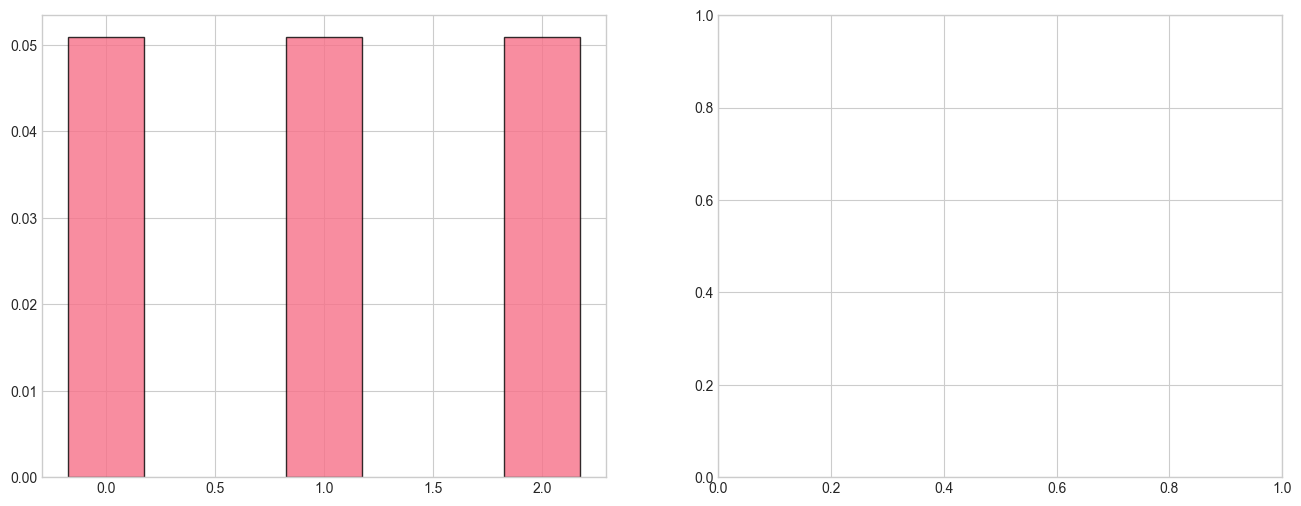

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 by Phase
ax = axes[0]
phases_list = sorted(comparison_df['Phase'].unique())
x = np.arange(len(phases_list))
width = 0.35
models_list = sorted(comparison_df['Model'].unique())

for i, model in enumerate(models_list[:2]):
    data = comparison_df[(comparison_df['Model'] == model)].sort_values('Phase')
    ax.bar(x + i*width, data['F1'].values, width, label=model, alpha=0.8, edgecolor='black')

ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('F1 Scores by Phase and Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels(phases_list)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# IoU by Phase
ax = axes[1]
for i, model in enumerate(models_list[:2]):
    data = comparison_df[(comparison_df['Model'] == model)].sort_values('Phase')
    ax.bar(x + i*width, data['IoU'].values, width, label=model, alpha=0.8, edgecolor='black')

ax.set_ylabel('Average IoU', fontsize=12, fontweight='bold')
ax.set_title('IoU Scores by Phase and Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels(phases_list)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations created")

## 6. Summary

In [ ]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

all_f1 = comparison_df['F1'].values
all_iou = comparison_df['IoU'].values

print(f"\nF1 Scores (all {len(all_f1)} evaluations):")
print(f"  Mean:   {np.mean(all_f1):.4f}")
print(f"  Median: {np.median(all_f1):.4f}")
print(f"  Std:    {np.std(all_f1):.4f}")
print(f"  Range:  [{np.min(all_f1):.4f}, {np.max(all_f1):.4f}]")

print(f"\nIoU Scores (all {len(all_iou)} evaluations):")
print(f"  Mean:   {np.mean(all_iou):.4f}")
print(f"  Median: {np.median(all_iou):.4f}")
print(f"  Std:    {np.std(all_iou):.4f}")
print(f"  Range:  [{np.min(all_iou):.4f}, {np.max(all_iou):.4f}]")

print(f"\n✓ PubLayNet evaluation complete!")


SUMMARY STATISTICS

F1 Scores (all 6 evaluations):
  Mean:   0.0758
  Median: 0.0775
  Std:    0.0431
  Range:  [0.0000, 0.1271]

IoU Scores (all 6 evaluations):
  Mean:   0.3288
  Median: 0.3438
  Std:    0.1821
  Range:  [0.0000, 0.6009]

✓ PubLayNet evaluation complete!
